# LIBS Corpus Data Analysis

Corpus-level PCA, peak width statistics, peak-shape PCA decomposition,
and PC-based peak characterisation.

**Prerequisites:** Run `background-pca` and `run-corpus-pca` to produce
the pickle files loaded below. See `README.md` for CLI usage.

In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import voigt_profile as voigt

## 1. Load pre-computed results

Results were computed on `moissanite` using `run_corpus_pca.py` against the
full LIBS corpus (4,909 spectra from `All_LIBS_Till_20260319`, 64 workers, 120s timeout).
Window width = 0.5x smallest-mode FWHM (0.156 nm half-window).
IncrementalPCA (10 components) on 13.5M peak windows completed in ~5 min.

In [2]:
RESULTS_FILE = 'jobs/corpus_pca_05x_10pc.pkl'

with open(RESULTS_FILE, 'rb') as f:
    results = pickle.load(f)

stats        = results['width_stats']
components   = results['components']
evr          = results['explained_variance_ratio']
mean_peak    = results['mean_peak']
mean_zeroed  = results['mean_peak_zeroed']
mean_offset  = results['mean_offset']
mean_fit     = results['mean_fit']
score_stats  = results['score_stats']
decomps      = results['decompositions']
metadata     = results['peak_metadata']
labels       = results['peak_classifications']
n_comp       = len(evr)
n_window_pts = components.shape[1]
x_norm       = np.linspace(-1, 1, n_window_pts)

# Pre-compute slider ranges from score statistics
score_std = score_stats['std']

print(f"Loaded results from {RESULTS_FILE}")
print(f"  {len(results['csv_files'])} spectra, {score_stats['n_samples']:,} peak windows, {n_comp} PCs")

Loaded results from jobs/corpus_pca_05x_10pc.pkl
  4909 spectra, 13,502,524 peak windows, 10 PCs


## 1b. Corpus-level PCA: detector artifacts and background

Full-spectrum PCA (4,909 spectra x 72,001 channels) identifies common-mode
features. The CCD detector has three physical segments joined at approximately
**375 nm** and **615 nm**. PCA components with disproportionate loading in
either junction zone are **artifact** components that can be subtracted.

Loaded jobs/bg_pca_new.pkl: 4909 spectra, 72001 channels, 20 components
Artifact components (junction-heavy): ['PC2', 'PC4', 'PC6', 'PC7', 'PC11', 'PC13', 'PC16', 'PC17', 'PC19', 'PC20']


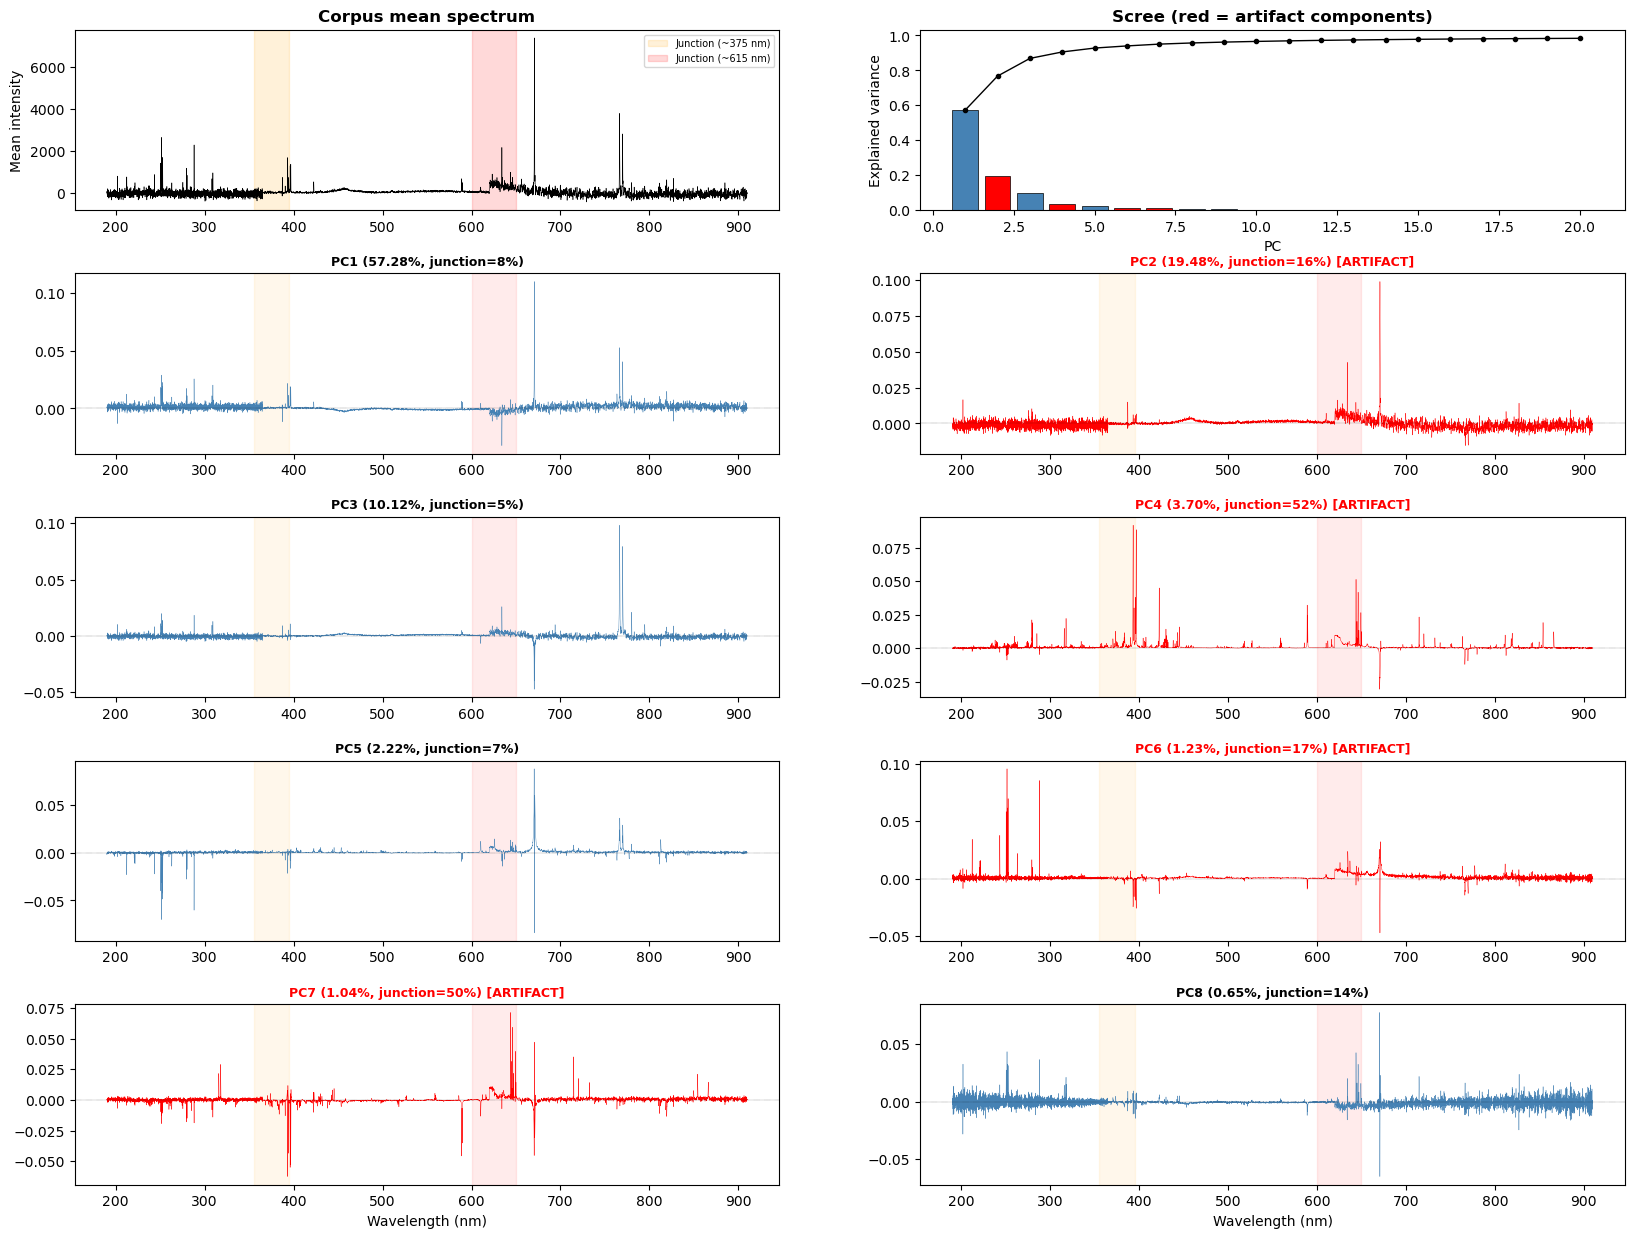

In [3]:
BG_FILE = 'jobs/bg_pca_new.pkl'
with open(BG_FILE, 'rb') as f:
    bg = pickle.load(f)

bg_wl = bg['wavelength']
bg_components = bg['components']
bg_evr = bg['explained_variance_ratio']
bg_mean = bg['mean']

# Define both junction zones
junction_zones = {
    'lower (~375 nm)': (bg_wl >= 355) & (bg_wl <= 395),
    'upper (~615 nm)': (bg_wl >= 600) & (bg_wl <= 650),
}

# Identify artifact components: concentrated in either junction zone
artifact_pcs = []
for i in range(len(bg_evr)):
    pc = bg_components[i]
    total_var = np.sum(pc**2)
    if total_var <= 0:
        continue
    for zone_name, zone_mask in junction_zones.items():
        zone_frac_expected = zone_mask.sum() / len(bg_wl)
        jfrac = np.sum(pc[zone_mask]**2) / total_var
        if jfrac > 2 * zone_frac_expected:
            artifact_pcs.append(i)
            break

print(f'Loaded {BG_FILE}: {bg["n_spectra"]} spectra, {bg["n_channels"]} channels, '
      f'{len(bg_evr)} components')
print(f'Artifact components (junction-heavy): {["PC"+str(i+1) for i in artifact_pcs]}')

# --- Plot ---
n_show = min(8, len(bg_evr))
fig = plt.figure(figsize=(20, 3 + 3 * ((n_show + 1) // 2)))
gs = fig.add_gridspec(1 + (n_show + 1) // 2, 2, hspace=0.35)

# Top: mean spectrum + scree
ax_mean = fig.add_subplot(gs[0, 0])
ax_mean.plot(bg_wl, bg_mean, 'k-', lw=0.4)
ax_mean.axvspan(355, 395, color='orange', alpha=0.15, label='Junction (~375 nm)')
ax_mean.axvspan(600, 650, color='red', alpha=0.15, label='Junction (~615 nm)')
ax_mean.set_ylabel('Mean intensity')
ax_mean.set_title('Corpus mean spectrum', fontweight='bold')
ax_mean.legend(fontsize=7)

ax_scree = fig.add_subplot(gs[0, 1])
colors_scree = ['red' if i in artifact_pcs else 'steelblue' for i in range(len(bg_evr))]
ax_scree.bar(range(1, len(bg_evr)+1), bg_evr, color=colors_scree, edgecolor='k', linewidth=0.5)
ax_scree.plot(range(1, len(bg_evr)+1), np.cumsum(bg_evr), 'ko-', ms=3, lw=1)
ax_scree.set_xlabel('PC')
ax_scree.set_ylabel('Explained variance')
ax_scree.set_title('Scree (red = artifact components)', fontweight='bold')

# PCs
# Combined junction mask for per-PC fraction display
junction_any = junction_zones['lower (~375 nm)'] | junction_zones['upper (~615 nm)']
for i in range(n_show):
    row = 1 + i // 2
    col = i % 2
    ax = fig.add_subplot(gs[row, col])
    pc = bg_components[i]
    jfrac = np.sum(pc[junction_any]**2) / np.sum(pc**2)
    is_art = i in artifact_pcs
    color = 'red' if is_art else 'steelblue'

    ax.plot(bg_wl, pc, color=color, lw=0.3)
    ax.axvspan(355, 395, color='orange', alpha=0.08)
    ax.axvspan(600, 650, color='red', alpha=0.08)
    ax.axhline(0, color='k', ls=':', lw=0.3)

    tag = ' [ARTIFACT]' if is_art else ''
    ax.set_title(f'PC{i+1} ({bg_evr[i]:.2%}, junction={jfrac:.0%}){tag}',
                 fontweight='bold', fontsize=9,
                 color='red' if is_art else 'black')
    if i >= n_show - 2:
        ax.set_xlabel('Wavelength (nm)')

plt.show()

### Detector segment model

The CCD detector has three segments joined at **365 nm** (UV/VIS) and
**620 nm** (VIS/NIR). Junction positions are stored in
`corrections/detector.json`. PCA components concentrated at these
boundaries are flagged as artifacts for per-segment removal.

DetectorModel
  wavelength range: 190.0 - 910.0 nm (72001 channels)
  junctions (2):
    365.0 nm  (zone=360.0-370.0 nm)
    620.0 nm  (zone=615.0-625.0 nm)
  segments (3):
    UV (seg 0): 190.0 - 365.0 nm (17500 channels, artifact PCs: [5])
    VIS (seg 1): 365.0 - 620.0 nm (25500 channels, artifact PCs: [3])
    NIR (seg 2): 620.0 - 910.0 nm (29001 channels, artifact PCs: [6, 10, 18, 19])
  artifact components: [3, 5, 6, 10, 12, 18, 19] (7 total)


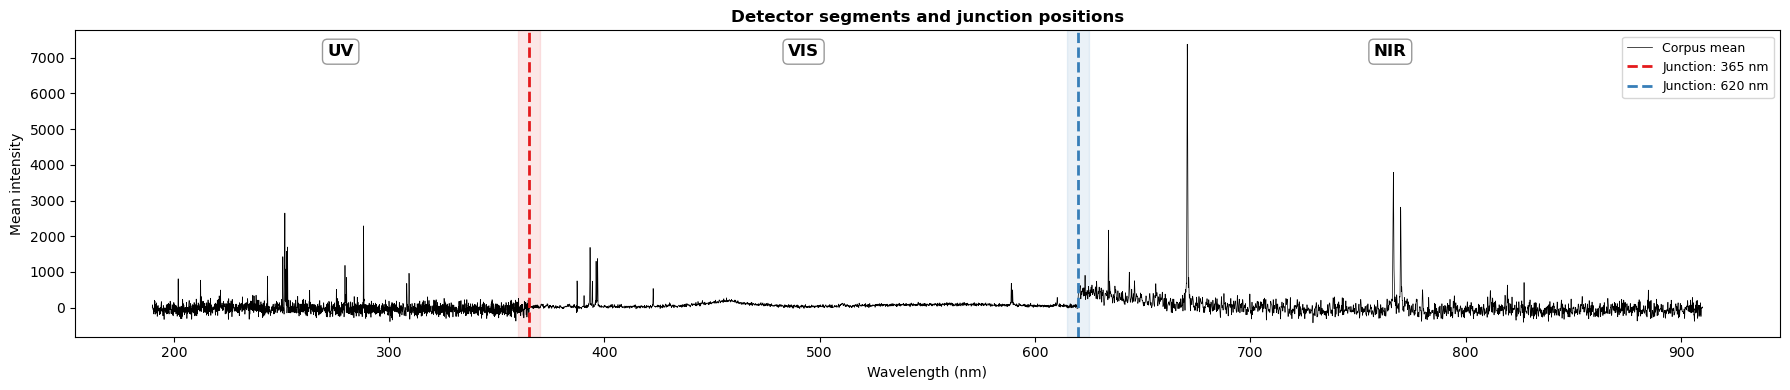


Artifact PCs: [3, 5, 6, 10, 12, 18, 19]
  UV: artifact PCs [5]
  VIS: artifact PCs [3]
  NIR: artifact PCs [6, 10, 18, 19]


In [4]:
from alibz.detector import DetectorModel

model = DetectorModel.from_pca(BG_FILE)

print(model.summary())

# --- Plot: corpus mean with junction positions ---
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(bg_wl, bg_mean, 'k-', lw=0.5, label='Corpus mean')

colors = ['#e41a1c', '#377eb8']  # red, blue
for junc, c in zip(model.junctions, colors):
    ax.axvline(junc.wavelength, color=c, ls='--', lw=2,
               label=f'Junction: {junc.wavelength:.0f} nm')
    ax.axvspan(junc.zone[0], junc.zone[1], color=c, alpha=0.1)

# Label segments
for seg in model.segments:
    mid = (seg.wl_lo + seg.wl_hi) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.95, seg.label,
            ha='center', va='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Mean intensity')
ax.set_title('Detector segments and junction positions', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Artifact summary
print(f'\nArtifact PCs: {model.artifact_components}')
for seg in model.segments:
    if seg.artifact_pcs:
        print(f'  {seg.label}: artifact PCs {seg.artifact_pcs}')

### Per-segment PCA

Re-run PCA on each detector segment individually. This separates the
instrument-specific variance (which differs across segments) from the
shared spectral physics, and reveals segment-specific artifacts that
the full-spectrum PCA may dilute.

Loaded per-segment PCA from jobs/bg_pca_segments.pkl (full re-decomposition)
UV (190.0-365.0 nm, 17500 channels): 20 PCs, cumulative = 98.3%
VIS (365.0-620.0 nm, 25500 channels): 20 PCs, cumulative = 99.1%
NIR (620.0-910.0 nm, 29001 channels): 20 PCs, cumulative = 99.2%


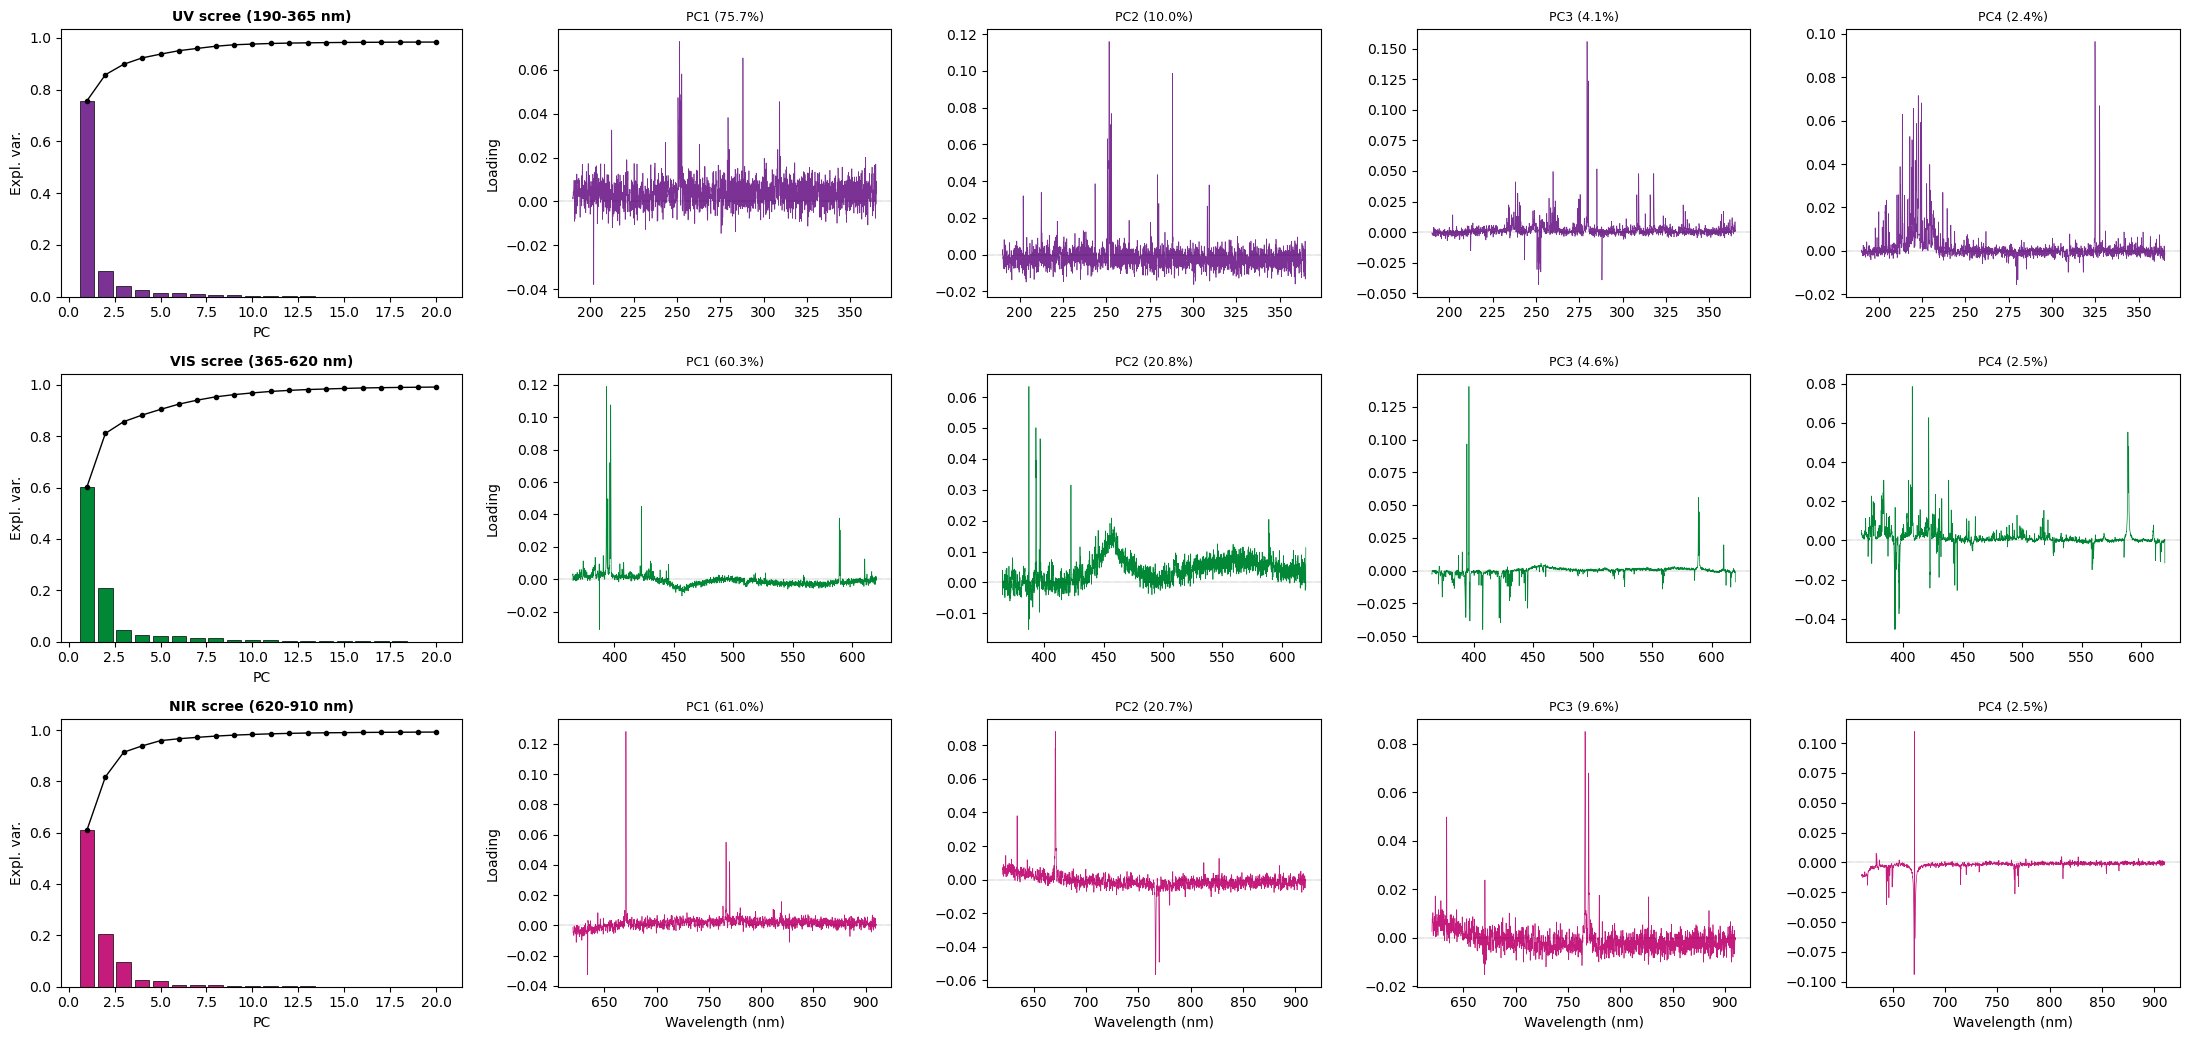

In [5]:
import os

# Try to load per-segment PCA from disk (produced by: background-pca --segment)
# Falls back to approximate reconstruction from full-spectrum PCA if not available.
BG_SEG_FILE = 'jobs/bg_pca_segments.pkl'

if os.path.exists(BG_SEG_FILE):
    with open(BG_SEG_FILE, 'rb') as f:
        bg_seg = pickle.load(f)
    seg_pca_results = {}
    for label, seg_data in bg_seg['segments'].items():
        seg_pca_results[label] = {
            'components': seg_data['components'],
            'evr': seg_data['explained_variance_ratio'],
            'mean': seg_data['mean'],
            'scores': seg_data['scores'],
            'wl': seg_data['wavelength'],
            'n_channels': seg_data['n_channels'],
        }
    print(f'Loaded per-segment PCA from {BG_SEG_FILE} (full re-decomposition)')
else:
    from sklearn.decomposition import PCA
    print(f'{BG_SEG_FILE} not found -- approximating from full-spectrum PCA')
    print('  Run: background-pca --segment /path/to/data --out jobs/bg_pca_segments.pkl')
    seg_pca_results = {}
    for seg in model.segments:
        sl = slice(seg.idx_lo, seg.idx_hi)
        seg_centered = bg['scores'] @ bg_components[:, sl]
        n_comp = min(10, seg_centered.shape[0], seg_centered.shape[1])
        pca = PCA(n_components=n_comp, random_state=42)
        seg_scores = pca.fit_transform(seg_centered)
        seg_pca_results[seg.label] = {
            'components': pca.components_,
            'evr': pca.explained_variance_ratio_,
            'mean': pca.mean_,
            'scores': seg_scores,
            'wl': bg_wl[sl],
            'n_channels': seg.idx_hi - seg.idx_lo,
        }

# --- Print summary ---
for label in ['UV', 'VIS', 'NIR']:
    if label not in seg_pca_results:
        continue
    res = seg_pca_results[label]
    evr = res['evr']
    wl_seg = res['wl']
    print(f'{label} ({wl_seg[0]:.1f}-{wl_seg[-1]:.1f} nm, '
          f'{res["n_channels"]} channels): '
          f'{len(evr)} PCs, '
          f'cumulative = {evr.sum():.1%}')

# --- Plot: per-segment scree + top 4 components ---
n_segs = len(seg_pca_results)
fig, axes = plt.subplots(n_segs, 5, figsize=(22, 3.5 * n_segs),
                         gridspec_kw={'width_ratios': [1.2, 1, 1, 1, 1]})
if n_segs == 1:
    axes = axes[np.newaxis, :]

seg_colors = {'UV': '#7b3294', 'VIS': '#008837', 'NIR': '#c51b7d'}

for row, label in enumerate(['UV', 'VIS', 'NIR']):
    if label not in seg_pca_results:
        continue
    res = seg_pca_results[label]
    evr = res['evr']
    wl_seg = res['wl']
    color = seg_colors.get(label, 'steelblue')

    # Scree
    ax = axes[row, 0]
    ax.bar(range(1, len(evr) + 1), evr, color=color, edgecolor='k', linewidth=0.5)
    ax.plot(range(1, len(evr) + 1), np.cumsum(evr), 'ko-', ms=3, lw=1)
    ax.set_xlabel('PC')
    ax.set_ylabel('Expl. var.')
    ax.set_title(f'{label} scree ({wl_seg[0]:.0f}-{wl_seg[-1]:.0f} nm)',
                 fontweight='bold', fontsize=10)

    # Top 4 components
    n_show = min(4, res['components'].shape[0])
    for ci in range(n_show):
        ax = axes[row, ci + 1]
        ax.plot(wl_seg, res['components'][ci], color=color, lw=0.5)
        ax.axhline(0, color='k', ls=':', lw=0.3)
        ax.set_title(f'PC{ci+1} ({evr[ci]:.1%})', fontsize=9)
        if ci == 0:
            ax.set_ylabel('Loading')
        if row == n_segs - 1:
            ax.set_xlabel('Wavelength (nm)')

plt.tight_layout()
plt.show()

## 2. Peak width statistics

Distribution of Voigt FWHM values across fitted spectra, shown both
for the full spectrum and broken down by detector segment (UV, VIS, NIR).

=== Overall ===
  min    FWHM: 0.0495 nm
  max    FWHM: 4.5497 nm
  mean   FWHM: 0.6544 nm
  median FWHM: 0.5117 nm
  std    FWHM: 0.4631 nm

UV (190-365 nm): 2,373,440 peaks, 5 modes
  mode 1: mean=0.1682 nm, std=0.0491 nm, weight=39.9%
  mode 2: mean=0.3093 nm, std=0.0664 nm, weight=42.1%
  mode 3: mean=0.5945 nm, std=0.1265 nm, weight=13.0%
  mode 4: mean=1.0790 nm, std=0.1462 nm, weight=3.0%
  mode 5: mean=1.6931 nm, std=0.3498 nm, weight=2.0%
VIS (365-620 nm): 4,485,328 peaks, 5 modes
  mode 1: mean=0.3426 nm, std=0.0719 nm, weight=47.3%
  mode 2: mean=0.5891 nm, std=0.1032 nm, weight=21.4%
  mode 3: mean=0.8445 nm, std=0.1156 nm, weight=17.1%
  mode 4: mean=1.1278 nm, std=0.1411 nm, weight=10.1%
  mode 5: mean=1.6728 nm, std=0.3422 nm, weight=4.1%
NIR (620-910 nm): 6,643,756 peaks, 5 modes
  mode 1: mean=0.3615 nm, std=0.1051 nm, weight=31.8%
  mode 2: mean=0.6043 nm, std=0.1117 nm, weight=32.6%
  mode 3: mean=1.0245 nm, std=0.1720 nm, weight=19.6%
  mode 4: mean=1.5386 nm, std=0

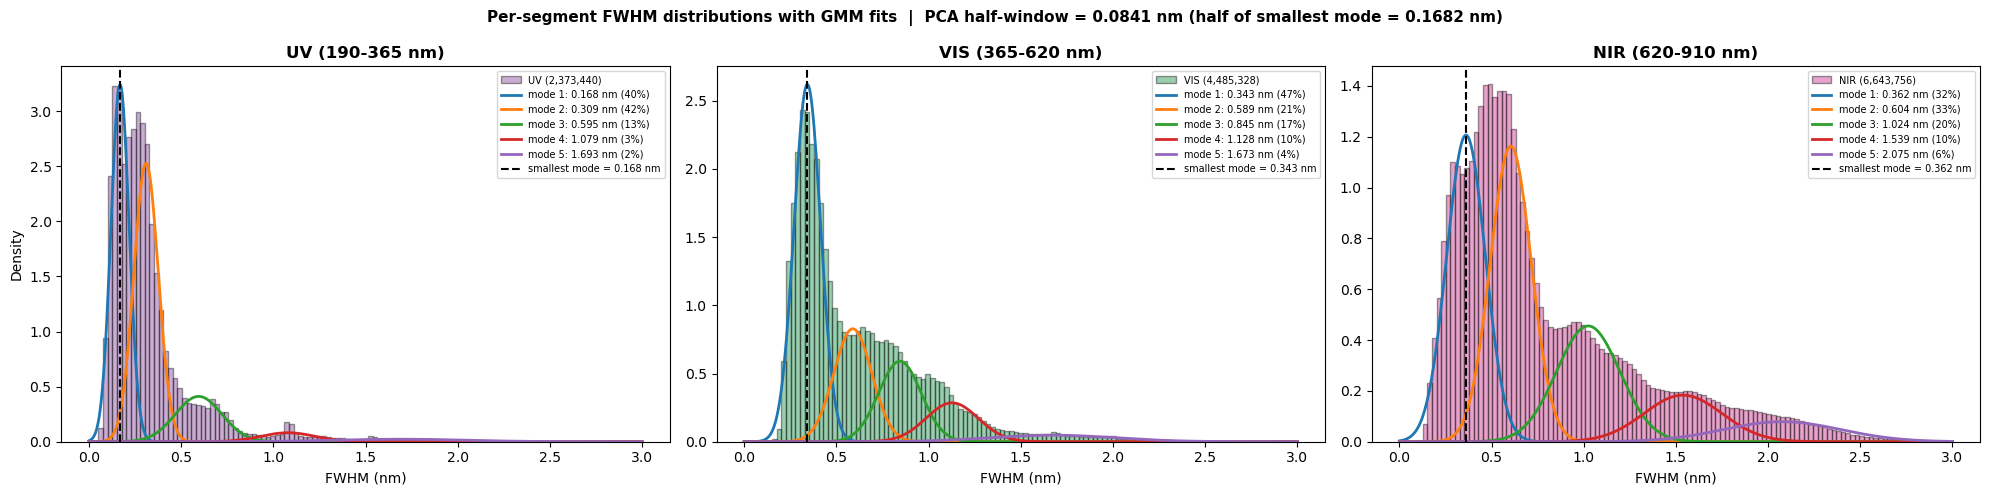

In [6]:
from sklearn.mixture import GaussianMixture

# --- Overall stats ---
all_widths = np.array(stats['all_widths'])
per_spectrum_median = np.array(stats['per_spectrum_median'])

print('=== Overall ===')
for key in ['min', 'max', 'mean', 'median', 'std']:
    print(f'  {key:6s} FWHM: {stats[key]:.4f} nm')

# --- Per-segment width breakdown ---
peak_wavelengths = np.array([m['mu'] for m in metadata])
peak_fwhms = np.array([m['fwhm'] for m in metadata])

seg_boundaries = [190.0, 365.0, 620.0, 910.0]
seg_labels = ['UV', 'VIS', 'NIR']
seg_colors = {'UV': '#7b3294', 'VIS': '#008837', 'NIR': '#c51b7d'}

seg_widths = {}
seg_gmm_results = {}

def fit_gmm(widths, label, max_components=5):
    """Fit GMM by BIC, return (best_gmm, means, stds, weights) sorted by mean."""
    X = widths.reshape(-1, 1)
    bics = {}
    for k in range(1, max_components + 1):
        gmm = GaussianMixture(n_components=k, random_state=0, max_iter=200).fit(X)
        bics[k] = gmm.bic(X)
    best_k = min(bics, key=bics.get)
    best_gmm = GaussianMixture(n_components=best_k, random_state=0, max_iter=200).fit(X)
    means = best_gmm.means_.ravel()
    stds = np.sqrt(best_gmm.covariances_.ravel())
    weights = best_gmm.weights_.ravel()
    order = np.argsort(means)
    return best_gmm, means[order], stds[order], weights[order], best_k

print()
global_smallest_mode = np.inf

for i, label in enumerate(seg_labels):
    mask = (peak_wavelengths >= seg_boundaries[i]) & (peak_wavelengths < seg_boundaries[i+1])
    w = peak_fwhms[mask]
    seg_widths[label] = w
    if len(w) < 10:
        print(f'{label}: too few peaks ({len(w)})')
        continue
    gmm, means, stds, weights, best_k = fit_gmm(w, label)
    seg_gmm_results[label] = {'gmm': gmm, 'means': means, 'stds': stds,
                               'weights': weights, 'n_modes': best_k}
    smallest = means[0]
    global_smallest_mode = min(global_smallest_mode, smallest)
    print(f'{label} ({seg_boundaries[i]:.0f}-{seg_boundaries[i+1]:.0f} nm): '
          f'{len(w):,} peaks, {best_k} mode{"s" if best_k > 1 else ""}')
    for j in range(best_k):
        print(f'  mode {j+1}: mean={means[j]:.4f} nm, '
              f'std={stds[j]:.4f} nm, weight={weights[j]:.1%}')

# Half of the smallest mode mean across all segments -> PCA window half-width
pca_half_window = global_smallest_mode / 2.0
print(f'\nSmallest mode mean (global): {global_smallest_mode:.4f} nm')
print(f'PCA peak-shape half-window:  {pca_half_window:.4f} nm')

# --- Plot: per-segment histograms with GMM overlays ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
bins = np.linspace(0, min(3.0, np.max(all_widths)), 120)
x_pdf = np.linspace(0, bins[-1], 500)

for idx, label in enumerate(seg_labels):
    ax = axes[idx]
    w = seg_widths[label]
    if len(w) == 0:
        ax.set_title(f'{label} (no data)')
        continue
    color = seg_colors[label]
    ax.hist(w, bins=bins, density=True, color=color, edgecolor='k', alpha=0.4,
            label=f'{label} ({len(w):,})')

    if label in seg_gmm_results:
        res = seg_gmm_results[label]
        for j in range(res['n_modes']):
            pdf_j = (res['weights'][j]
                     * (1 / (res['stds'][j] * np.sqrt(2 * np.pi)))
                     * np.exp(-0.5 * ((x_pdf - res['means'][j]) / res['stds'][j])**2))
            ax.plot(x_pdf, pdf_j, lw=2,
                    label=f'mode {j+1}: {res["means"][j]:.3f} nm ({res["weights"][j]:.0%})')
        ax.axvline(res['means'][0], color='k', ls='--', lw=1.5,
                   label=f'smallest mode = {res["means"][0]:.3f} nm')

    ax.set_xlabel('FWHM (nm)')
    if idx == 0:
        ax.set_ylabel('Density')
    ax.set_title(f'{label} ({seg_boundaries[idx]:.0f}-{seg_boundaries[idx+1]:.0f} nm)',
                 fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle(f'Per-segment FWHM distributions with GMM fits  |  '
             f'PCA half-window = {pca_half_window:.4f} nm '
             f'(half of smallest mode = {global_smallest_mode:.4f} nm)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Peak-shape PCA by detector segment

Peak-shape windows are extracted from the fitted corpus spectra,
baseline-subtracted, normalised, and resampled to 101 points.
We analyse the peak shapes separately for each detector segment
(UV, VIS, NIR) since each has different resolution, noise floor,
and broadening characteristics.

Total: 13,502,524 peak windows, 10 PCs
Overall cumulative variance: 99.2%

  UV: 2,373,440 peaks (17.6%)
  VIS: 4,485,328 peaks (33.2%)
  NIR: 6,643,756 peaks (49.2%)


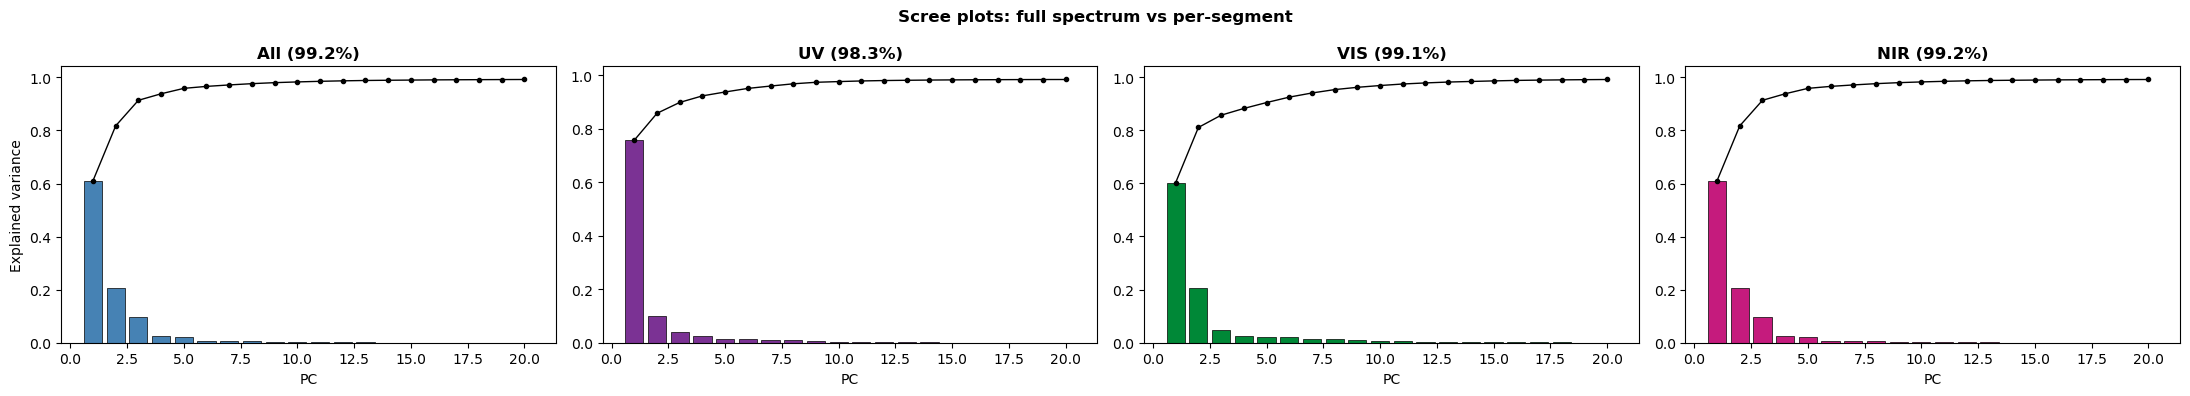

In [7]:
# --- Classify peaks by segment ---
peak_wls = np.array([m['mu'] for m in metadata])
seg_bounds = [190.0, 365.0, 620.0, 910.0]
seg_names = ['UV', 'VIS', 'NIR']
seg_colors_map = {'UV': '#7b3294', 'VIS': '#008837', 'NIR': '#c51b7d'}

seg_peak_masks = {}
for i, name in enumerate(seg_names):
    seg_peak_masks[name] = (peak_wls >= seg_bounds[i]) & (peak_wls < seg_bounds[i+1])

print(f'Total: {score_stats["n_samples"]:,} peak windows, {n_comp} PCs')
print(f'Overall cumulative variance: {np.cumsum(evr)[-1]:.1%}\n')
for name in seg_names:
    n = seg_peak_masks[name].sum()
    print(f'  {name}: {n:,} peaks ({n/len(peak_wls):.1%})')

# --- Per-segment scree comparison ---
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

# Overall
ax = axes[0]
n_bg = len(evr)
ax.bar(range(1, n_bg+1), evr, color='steelblue', edgecolor='k', lw=0.5)
ax.plot(range(1, n_bg+1), np.cumsum(evr), 'ko-', ms=3, lw=1)
ax.set_xlabel('PC')
ax.set_ylabel('Explained variance')
ax.set_title(f'All ({np.cumsum(evr)[-1]:.1%})', fontweight='bold')

# Per-segment (from bg_pca_segments if available)
for idx, name in enumerate(seg_names):
    ax = axes[idx + 1]
    color = seg_colors_map[name]
    if name in seg_pca_results:
        seg_evr = seg_pca_results[name]['evr']
        ax.bar(range(1, len(seg_evr)+1), seg_evr, color=color, edgecolor='k', lw=0.5)
        ax.plot(range(1, len(seg_evr)+1), np.cumsum(seg_evr), 'ko-', ms=3, lw=1)
        ax.set_title(f'{name} ({seg_evr.sum():.1%})', fontweight='bold')
    else:
        ax.set_title(f'{name} (no segment PCA)')
    ax.set_xlabel('PC')

plt.suptitle('Scree plots: full spectrum vs per-segment', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### 3a. Per-segment mean spectra and top principal components

Each segment's PCA captures different physics:
- **UV**: dense, overlapping lines from excited states; strong instrumental broadening
- **VIS**: dominant resonance lines; mixed Doppler + Stark broadening
- **NIR**: sparser lines; broader features, stronger Lorentzian tails

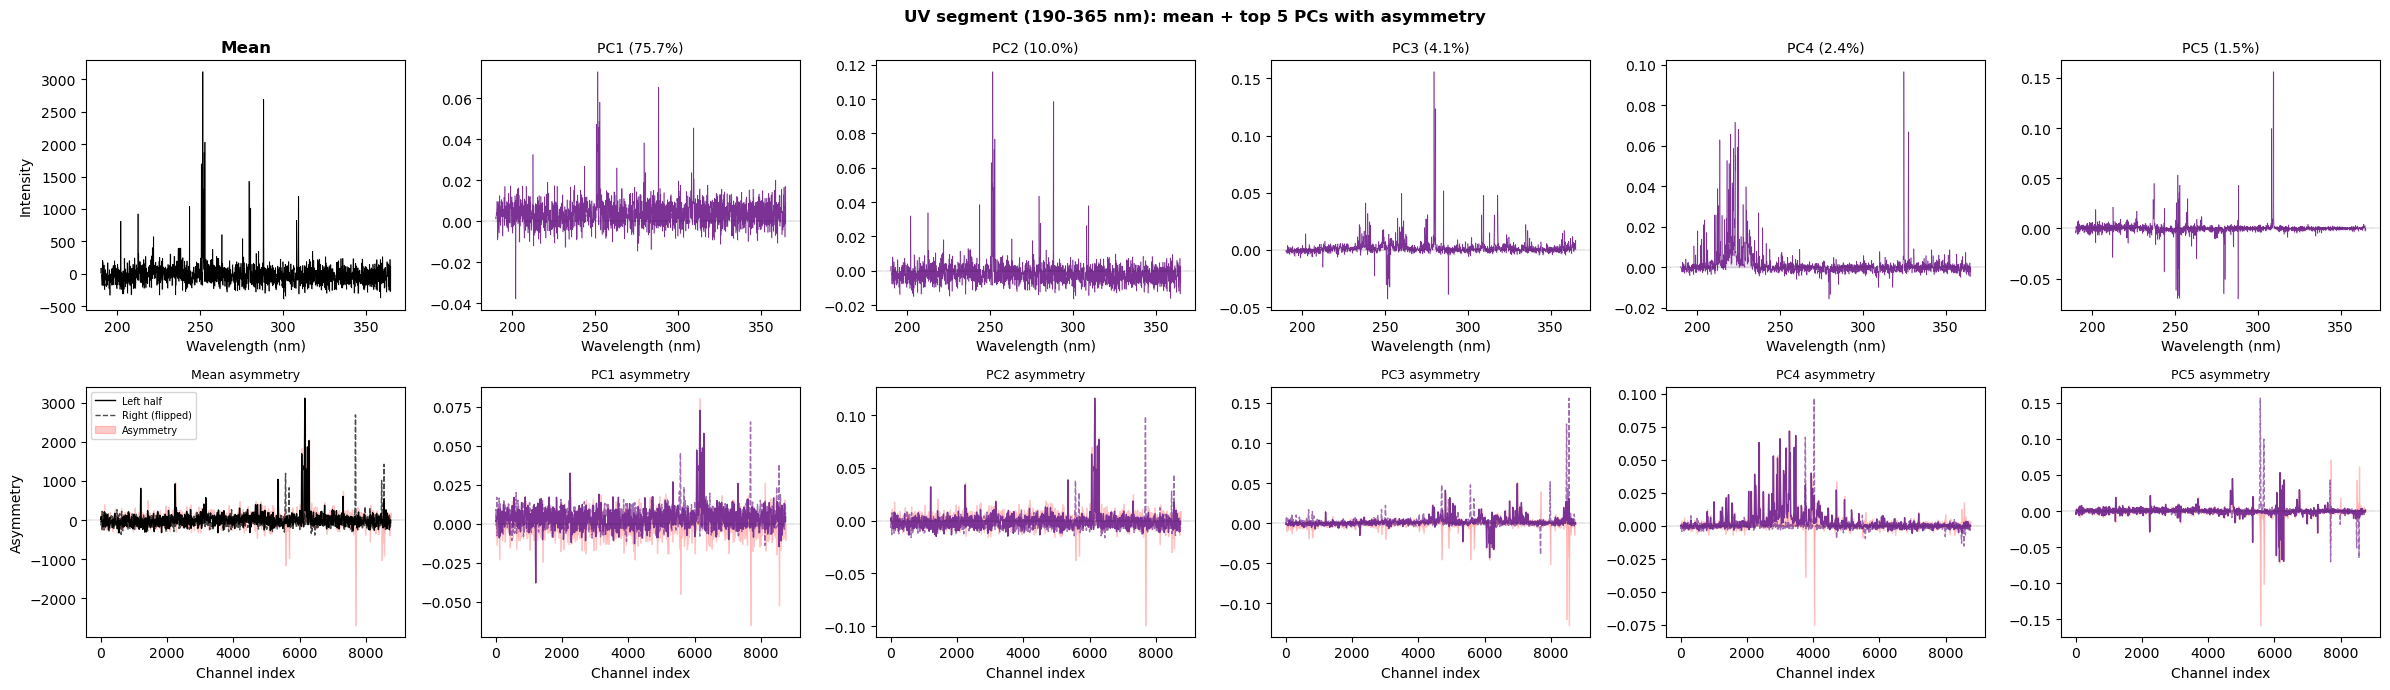

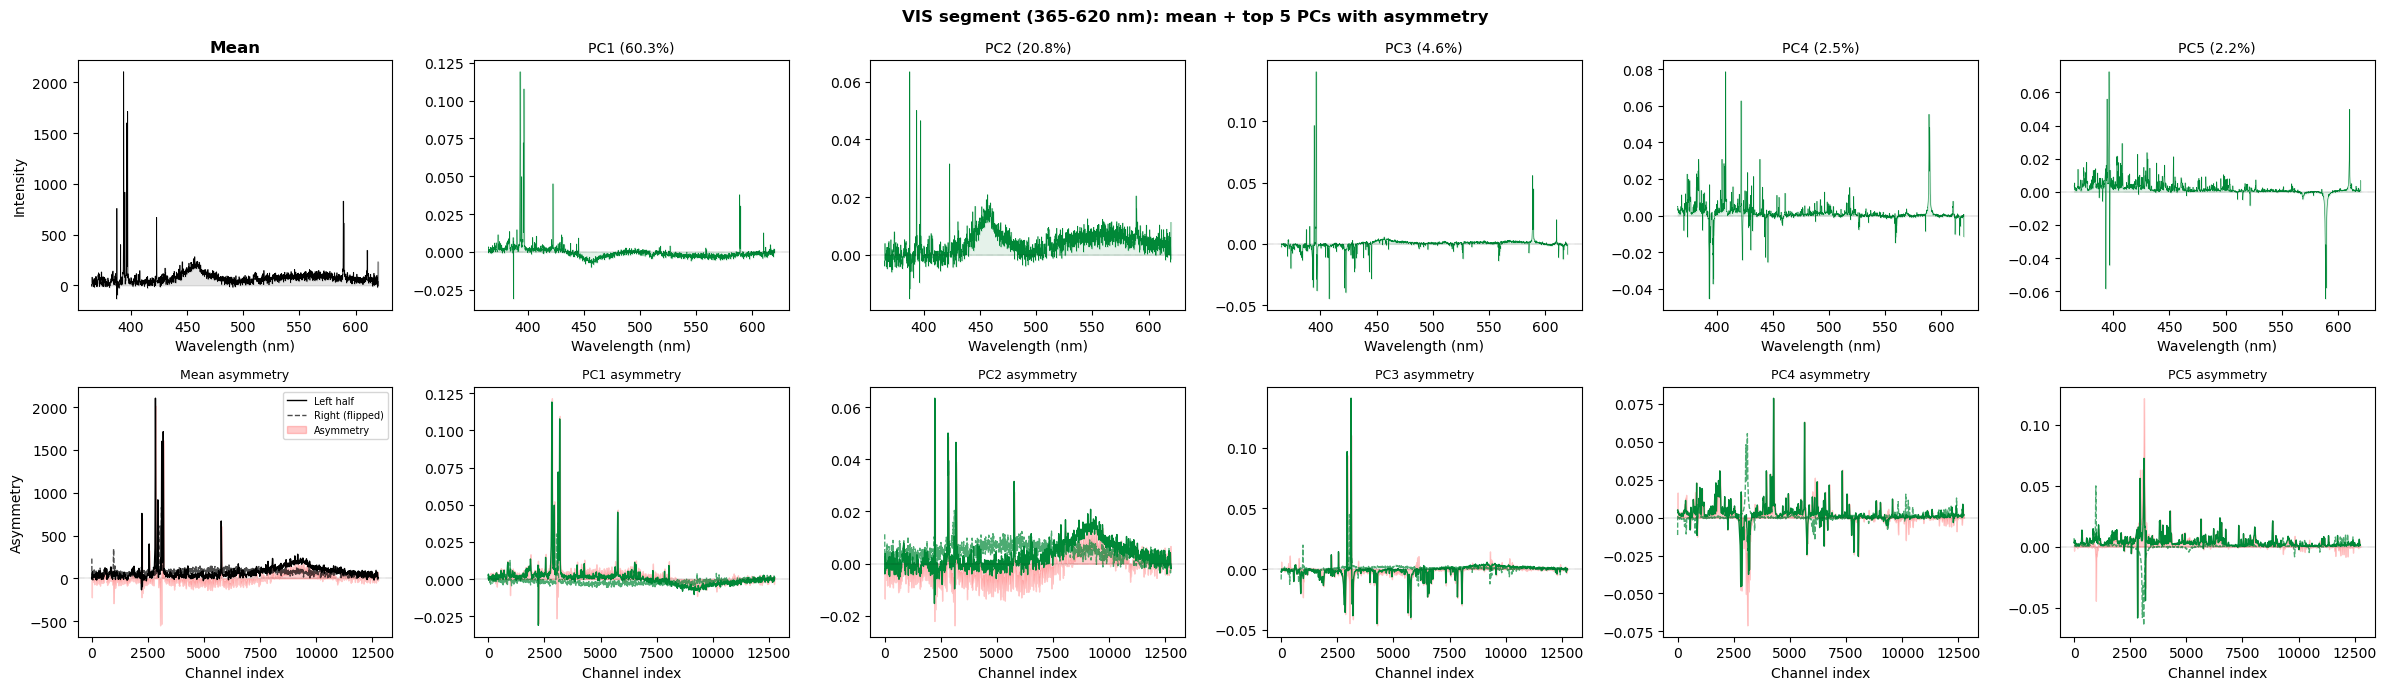

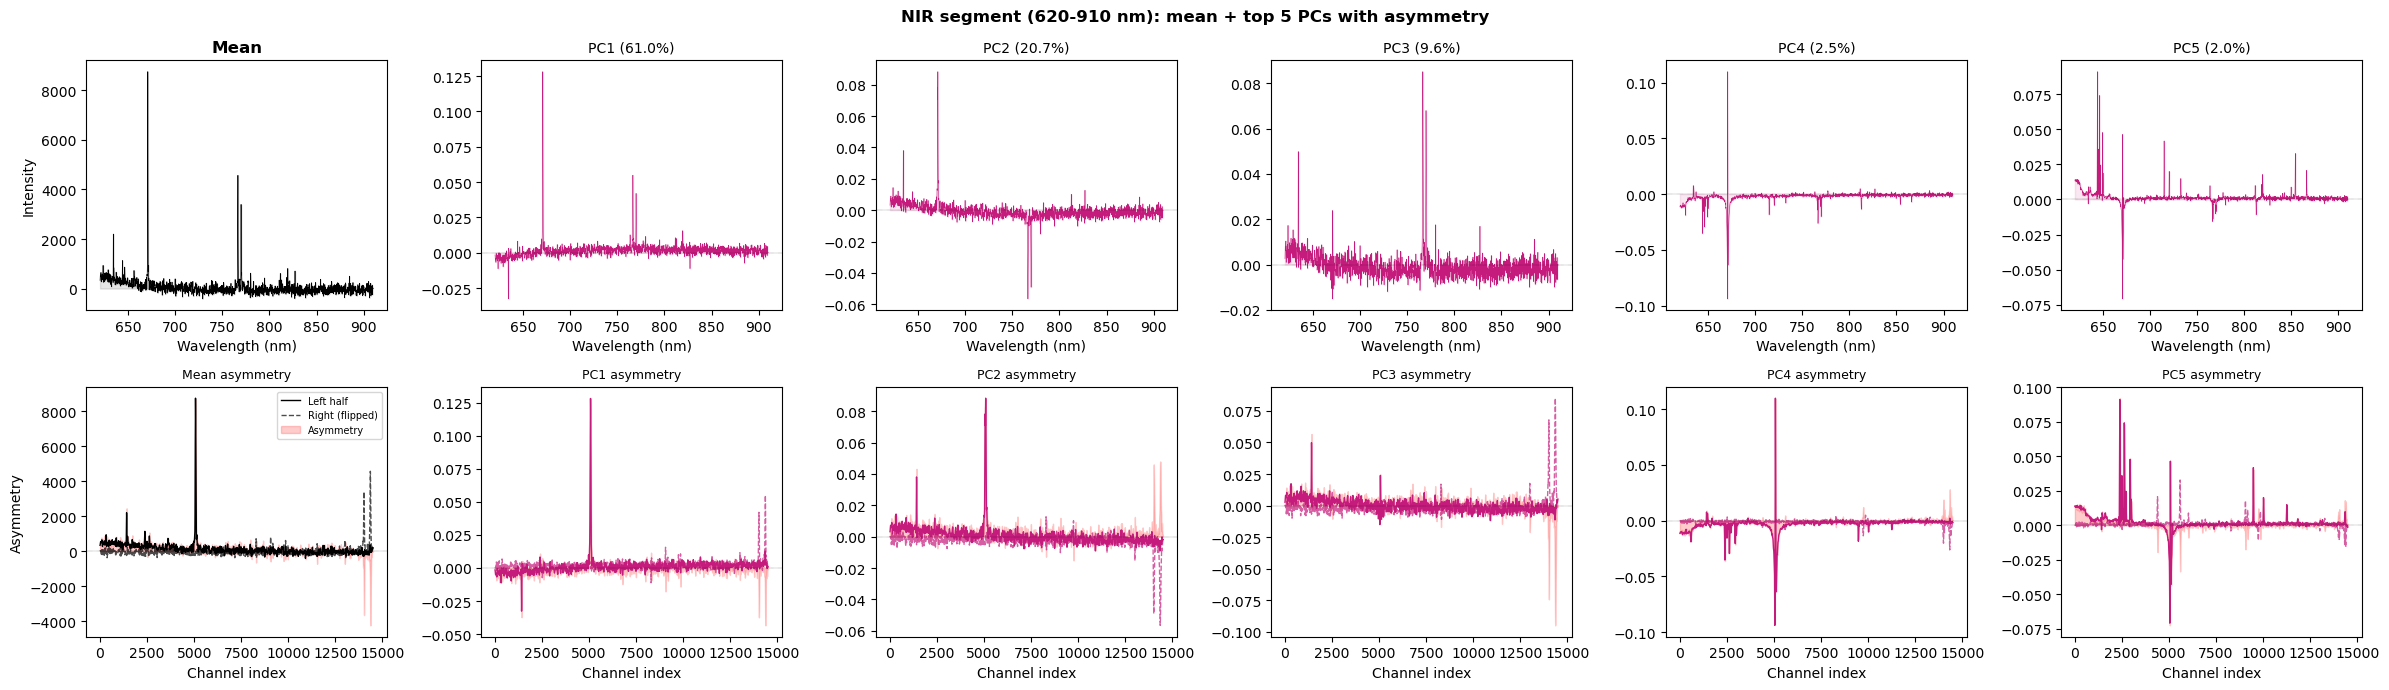

In [8]:
# --- Per-segment: mean + top PCs with asymmetry overlay ---
n_pc_show = 5

for seg_name in seg_names:
    if seg_name not in seg_pca_results:
        continue
    res = seg_pca_results[seg_name]
    wl_seg = res['wl']
    color = seg_colors_map[seg_name]
    n_show = min(n_pc_show, res['components'].shape[0])
    n_cols = n_show + 1  # mean + PCs

    fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 7),
                             sharex='row')

    # --- Top row: mean and each PC ---
    # Mean
    ax = axes[0, 0]
    ax.plot(wl_seg, res['mean'], 'k-', lw=0.5)
    ax.fill_between(wl_seg, res['mean'], alpha=0.1, color='k')
    ax.set_title('Mean', fontweight='bold')
    ax.set_ylabel('Intensity')

    for ci in range(n_show):
        ax = axes[0, ci + 1]
        pc = res['components'][ci]
        ax.plot(wl_seg, pc, color=color, lw=0.4)
        ax.fill_between(wl_seg, pc, alpha=0.1, color=color)
        ax.axhline(0, color='k', ls=':', lw=0.3)
        ax.set_title(f'PC{ci+1} ({res["evr"][ci]:.1%})', fontsize=10)

    # --- Bottom row: asymmetry overlay (left half vs flipped right half) ---
    def plot_asymmetry(ax, profile, wl, label, color):
        """Overlay left half and flipped right half to visualise asymmetry."""
        mid = len(profile) // 2
        left = profile[:mid]
        right_flipped = profile[mid + (1 if len(profile) % 2 else 0):][::-1]
        n = min(len(left), len(right_flipped))
        x_half = np.arange(n)
        ax.plot(x_half, left[:n], color=color, lw=1, label='Left half')
        ax.plot(x_half, right_flipped[:n], color=color, lw=1, ls='--',
                alpha=0.7, label='Right (flipped)')
        diff = left[:n] - right_flipped[:n]
        ax.fill_between(x_half, diff, alpha=0.2, color='red',
                        label='Asymmetry')
        ax.axhline(0, color='k', ls=':', lw=0.3)
        ax.set_title(f'{label} asymmetry', fontsize=9)

    plot_asymmetry(axes[1, 0], res['mean'], wl_seg, 'Mean', 'k')
    axes[1, 0].set_ylabel('Asymmetry')
    axes[1, 0].legend(fontsize=7)

    for ci in range(n_show):
        plot_asymmetry(axes[1, ci + 1], res['components'][ci],
                       wl_seg, f'PC{ci+1}', color)

    for ax in axes[0, :]:
        ax.set_xlabel('Wavelength (nm)')
    for ax in axes[1, :]:
        ax.set_xlabel('Channel index')

    fig.suptitle(f'{seg_name} segment ({wl_seg[0]:.0f}-{wl_seg[-1]:.0f} nm): '
                 f'mean + top {n_show} PCs with asymmetry',
                 fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

### 3a-ii. Peak-shape PCs by segment

The peak-shape PCA (101-point normalised windows, used for reconstruction
in section 3d) was trained on the full corpus. Here we plot the overall
mean peak and each PC, then overlay the per-segment mean peak shapes
to show how the typical peak profile differs across UV, VIS, and NIR.

Full scores not available — showing overall mean for all segments


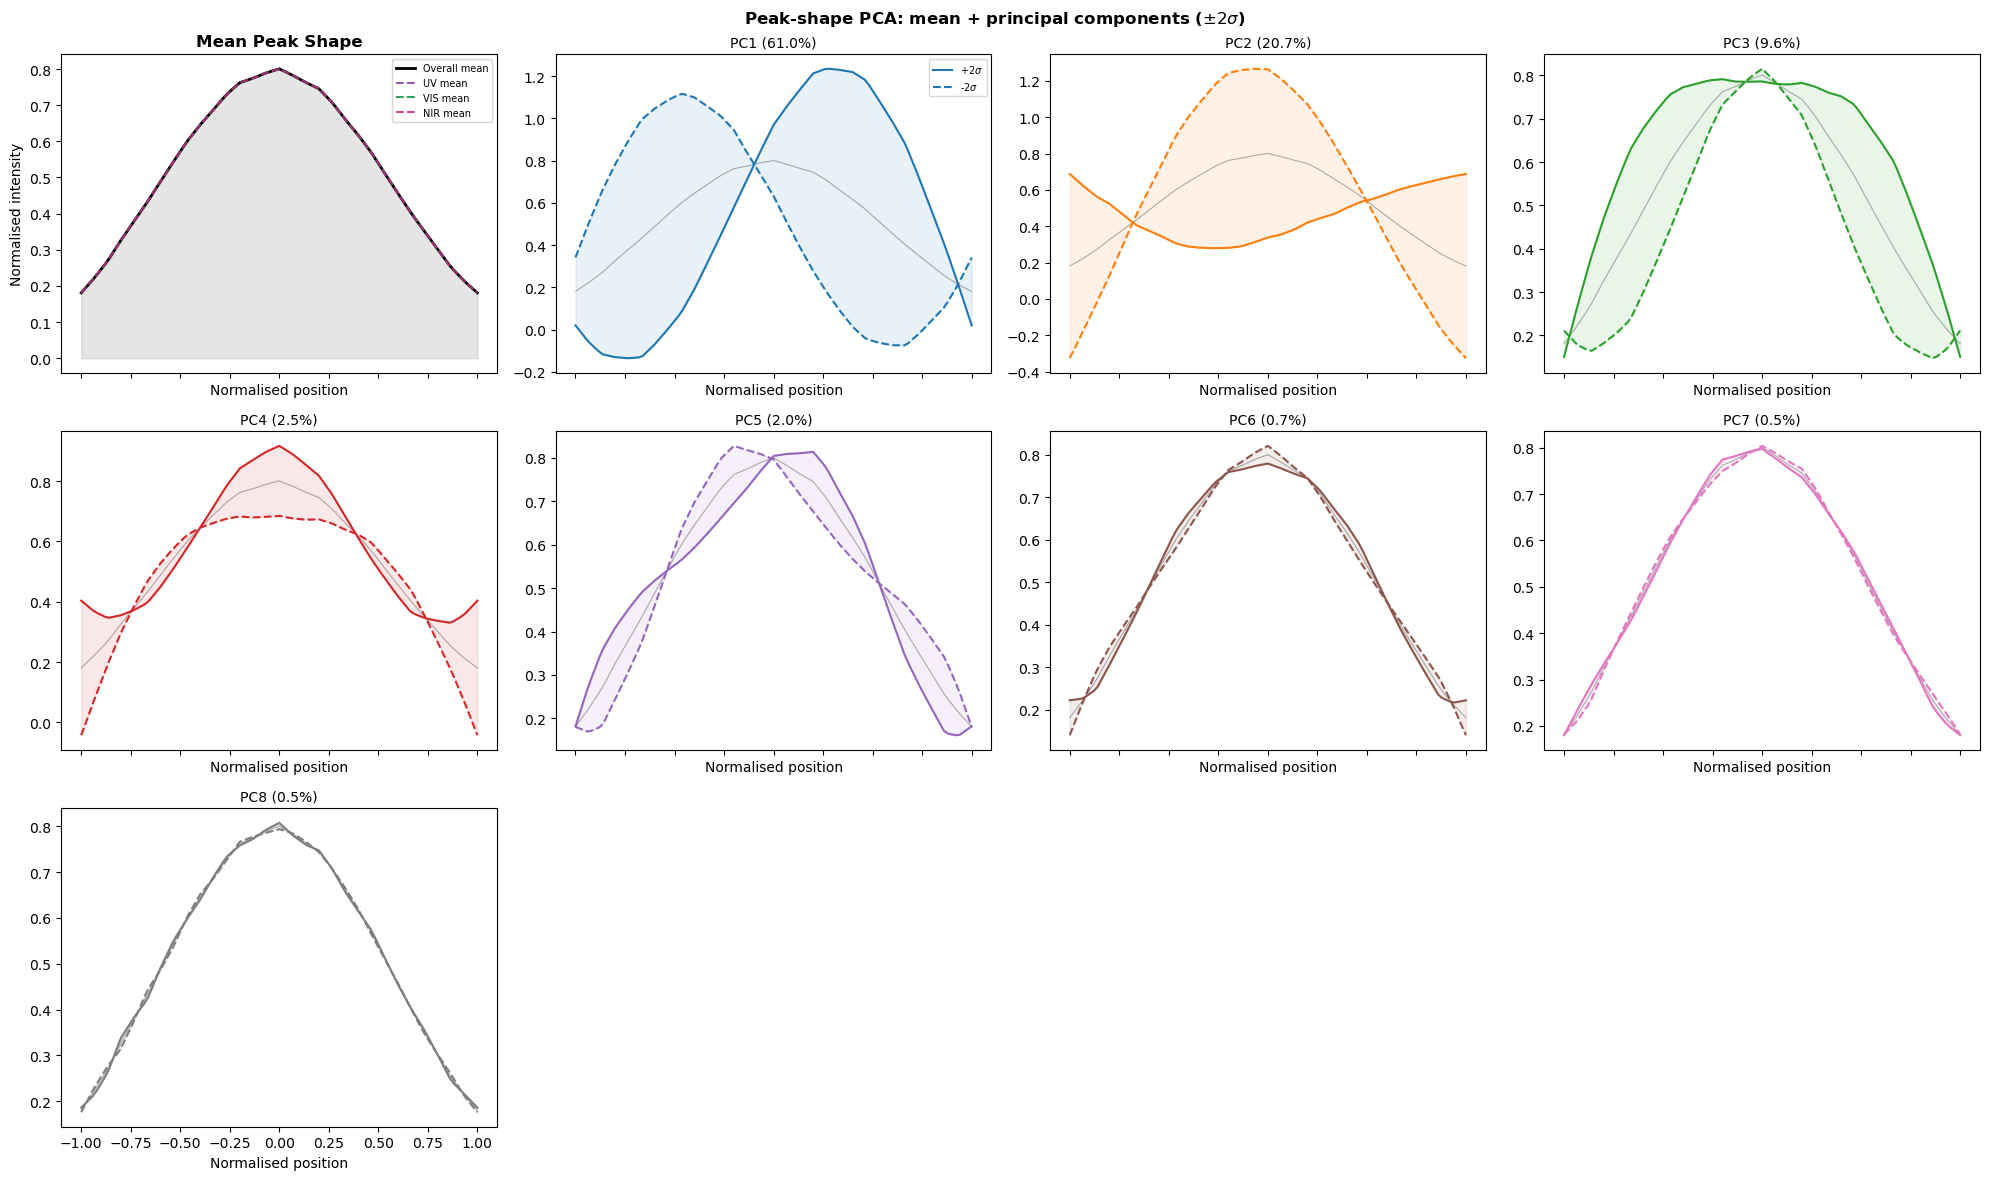

In [9]:
# --- Peak-shape PCs with per-segment mean overlays ---
x_win = np.linspace(-1, 1, n_window_pts)

# Reconstruct per-segment mean peak shapes by averaging the
# normalised windows for peaks in each segment.
# We don't have per-peak windows stored, but we can approximate
# from the PCA: mean_peak + mean_scores @ components.
# Since score_stats only has overall stats, we use the metadata
# to identify which peaks are in each segment, then compute
# the segment mean from the scores if available.
#
# If full scores aren't available (only summary stats), we show
# the overall mean and note the limitation.

# Try to get per-peak scores from the results file
has_full_scores = 'scores' in results and results['scores'] is not None

seg_mean_peaks = {}
if has_full_scores:
    all_scores = results['scores']  # (n_peaks, n_comp)
    for name in seg_names:
        mask = seg_peak_masks[name]
        if mask.sum() > 0:
            seg_scores_mean = np.mean(all_scores[mask], axis=0)
            seg_mean_peaks[name] = mean_peak + seg_scores_mean @ components
    print('Per-segment mean peaks reconstructed from full score matrix')
else:
    print('Full scores not available — showing overall mean for all segments')
    for name in seg_names:
        seg_mean_peaks[name] = mean_peak.copy()

# --- Plot: mean + each PC, with per-segment mean overlaid ---
n_show = min(n_comp, 8)
n_cols = 4
n_panels = n_show + 1  # mean + PCs
n_rows = (n_panels + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                         sharex=True)
axes = axes.flatten()

# Panel 0: mean peak shape with per-segment means
ax = axes[0]
ax.plot(x_win, mean_peak, 'k-', lw=2, label='Overall mean')
ax.fill_between(x_win, mean_peak, alpha=0.1, color='k')
for name in seg_names:
    if name in seg_mean_peaks:
        ax.plot(x_win, seg_mean_peaks[name], color=seg_colors_map[name],
                lw=1.5, ls='--', alpha=0.8, label=f'{name} mean')
ax.set_title('Mean Peak Shape', fontweight='bold')
ax.set_ylabel('Normalised intensity')
ax.legend(fontsize=7)

# Panels 1..n_show: each PC + perturbation on the mean
pc_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
             '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

for ci in range(n_show):
    ax = axes[ci + 1]
    pc = components[ci]

    # Show mean (grey) and mean +/- 2*std*PC
    ax.plot(x_win, mean_peak, 'k-', lw=0.8, alpha=0.3)
    std_i = score_std[ci] if ci < len(score_std) else 1.0
    ax.plot(x_win, mean_peak + 2 * std_i * pc,
            color=pc_colors[ci % len(pc_colors)], lw=1.5, label=f'+2$\\sigma$')
    ax.plot(x_win, mean_peak - 2 * std_i * pc,
            color=pc_colors[ci % len(pc_colors)], lw=1.5, ls='--', label=f'-2$\\sigma$')
    ax.fill_between(x_win,
                    mean_peak - 2 * std_i * pc,
                    mean_peak + 2 * std_i * pc,
                    alpha=0.1, color=pc_colors[ci % len(pc_colors)])
    ax.set_title(f'PC{ci+1} ({evr[ci] if ci < len(evr) else 0:.1%})', fontsize=10)
    if ci == 0:
        ax.legend(fontsize=7)

# Hide unused panels
for j in range(n_panels, len(axes)):
    axes[j].set_visible(False)

for ax in axes[:n_panels]:
    ax.set_xlabel('Normalised position')

fig.suptitle('Peak-shape PCA: mean + principal components ($\\pm 2\\sigma$)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# --- Per-segment comparison: how does each PC shift differ by segment? ---
if has_full_scores:
    fig, axes = plt.subplots(1, min(4, n_comp), figsize=(5 * min(4, n_comp), 4))
    if min(4, n_comp) == 1:
        axes = [axes]

    for ci, ax in enumerate(axes):
        ax.plot(x_win, mean_peak, 'k-', lw=0.8, alpha=0.3, label='Overall mean')
        for name in seg_names:
            if name not in seg_mean_peaks:
                continue
            mask = seg_peak_masks[name]
            seg_score_mean = np.mean(all_scores[mask, ci])
            seg_score_std = np.std(all_scores[mask, ci])
            perturbed = seg_mean_peaks[name] + seg_score_std * components[ci]
            ax.plot(x_win, seg_mean_peaks[name], color=seg_colors_map[name],
                    lw=1.5, label=f'{name} mean')
        ax.set_title(f'PC{ci+1}: segment means', fontsize=10, fontweight='bold')
        ax.set_xlabel('Normalised position')
        if ci == 0:
            ax.set_ylabel('Normalised intensity')
            ax.legend(fontsize=7)

    plt.suptitle('Per-segment mean peak shapes on the peak-shape PCA basis',
                 fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

### 3b. Peak-shape parameters by segment

Distribution of Voigt profile parameters (sigma, gamma, FWHM) and
the Gaussian/Lorentzian balance for peaks in each detector segment.

UV: 2,373,440 peaks, median sigma=0.0693, gamma=0.0815, FWHM=0.2671, G-frac=0.46
VIS: 4,485,328 peaks, median sigma=0.1271, gamma=0.1497, FWHM=0.4902, G-frac=0.46
NIR: 6,643,756 peaks, median sigma=0.1597, gamma=0.1881, FWHM=0.6159, G-frac=0.46


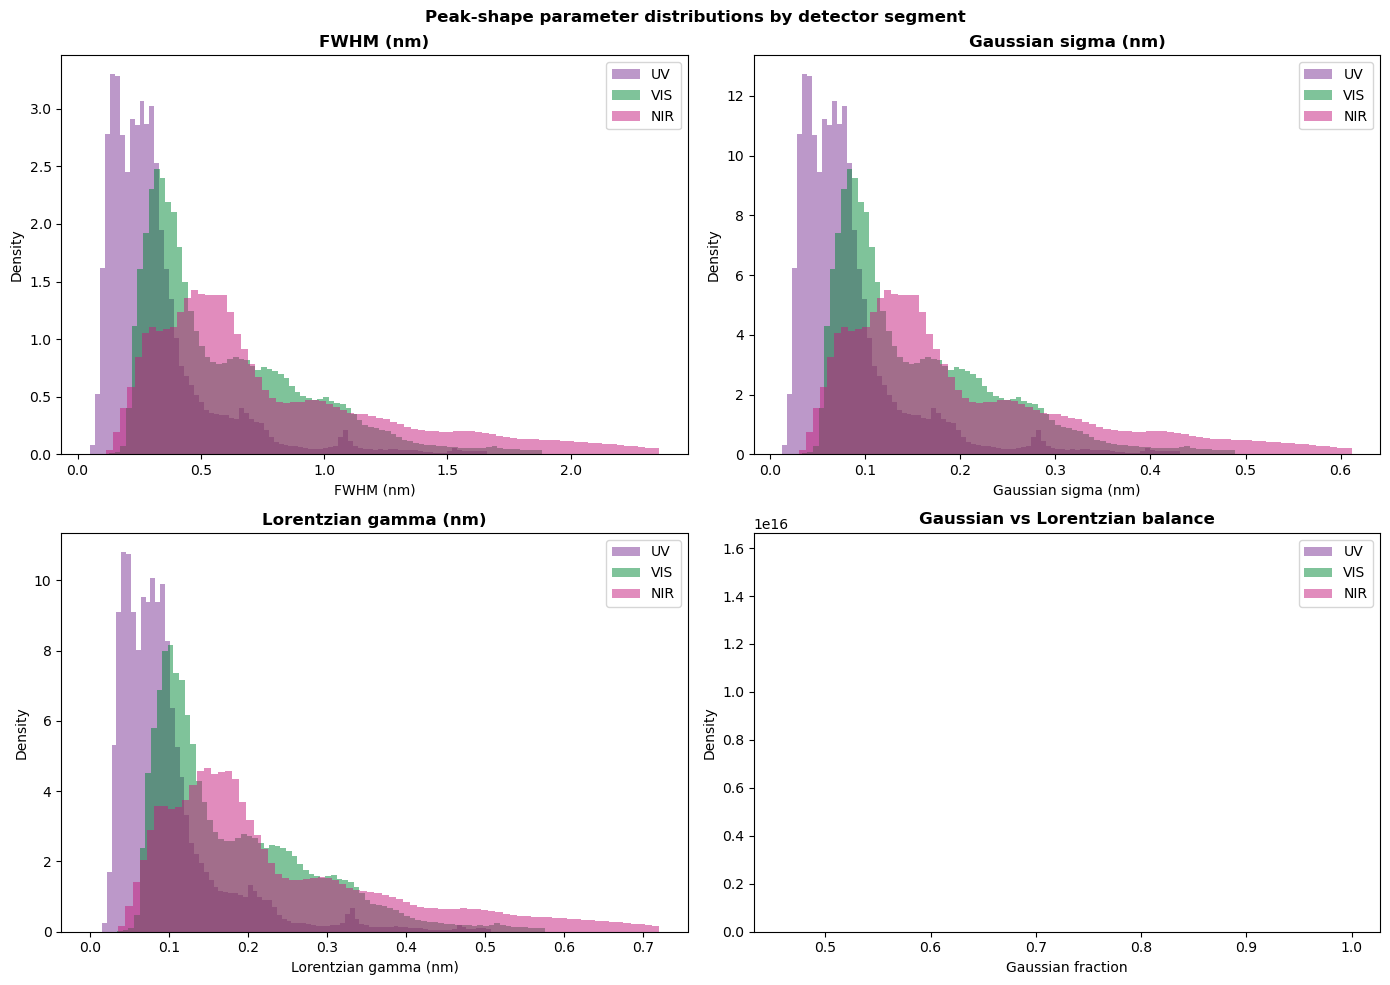

In [10]:
# --- Per-segment Voigt parameter distributions ---
for name in seg_names:
    mask = seg_peak_masks[name]
    n_seg = mask.sum()
    if n_seg == 0:
        continue
    seg_meta = [m for m, keep in zip(metadata, mask) if keep]
    seg_sigmas = np.array([m['sigma'] for m in seg_meta])
    seg_gammas = np.array([m['gamma'] for m in seg_meta])
    seg_fwhms = np.array([m['fwhm'] for m in seg_meta])
    total = seg_sigmas + seg_gammas
    g_frac = np.where(total > 0, seg_sigmas / total, 0.5)
    print(f'{name}: {n_seg:,} peaks, '
          f'median sigma={np.median(seg_sigmas):.4f}, '
          f'gamma={np.median(seg_gammas):.4f}, '
          f'FWHM={np.median(seg_fwhms):.4f}, '
          f'G-frac={np.median(g_frac):.2f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

param_data = [
    ('fwhm', 'FWHM (nm)', axes[0, 0]),
    ('sigma', 'Gaussian sigma (nm)', axes[0, 1]),
    ('gamma', 'Lorentzian gamma (nm)', axes[1, 0]),
]

for param, plabel, ax in param_data:
    for name in seg_names:
        mask = seg_peak_masks[name]
        if mask.sum() == 0: continue
        vals = np.array([m[param] for m in metadata])[mask]
        vals = vals[vals < np.percentile(vals, 99)]
        ax.hist(vals, bins=80, density=True, alpha=0.5,
                color=seg_colors_map[name], label=name)
    ax.set_xlabel(plabel)
    ax.set_ylabel('Density')
    ax.set_title(plabel, fontweight='bold')
    ax.legend()

# Gaussian fraction
ax = axes[1, 1]
for name in seg_names:
    mask = seg_peak_masks[name]
    if mask.sum() == 0: continue
    sigmas = np.array([m['sigma'] for m in metadata])[mask]
    gammas = np.array([m['gamma'] for m in metadata])[mask]
    total = sigmas + gammas
    gf = np.where(total > 0, sigmas / total, 0.5)
    n_unique = len(np.unique(np.round(gf, 6)))
    n_bins = min(50, max(2, n_unique // 2))
    ax.hist(gf, bins=n_bins, density=True, alpha=0.5,
            color=seg_colors_map[name], label=name)
ax.set_xlabel('Gaussian fraction')
ax.set_ylabel('Density')
ax.set_title('Gaussian vs Lorentzian balance', fontweight='bold')
ax.legend()

plt.suptitle('Peak-shape parameter distributions by detector segment',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### 3c. Asymmetry analysis by segment

Self-absorption produces asymmetric peak profiles. We quantify this
per segment to see whether it varies across the detector.

=== UV (190-365 nm) ===
 Profile    Centroid    Skewness       dArea
    Mean     -0.0318     +0.1152     +0.0505
     PC1     -0.0109     +0.0345     +0.0219
     PC2     -0.0137     +0.0546     +0.0235
     PC3     -0.0212     +0.2375     +0.0391
     PC4     -0.2768     +0.8909     +0.4139
     PC5     -0.1409     +0.2565     +0.2207

=== VIS (365-620 nm) ===
 Profile    Centroid    Skewness       dArea
    Mean     -0.0100     +0.0693     +0.0757
     PC1     -0.1598     +0.3649     +0.2552
     PC2     +0.0786     -0.1128     -0.0393
     PC3     -0.2320     +0.6580     +0.3792
     PC4     -0.3205     +0.8899     +0.4474
     PC5     -0.2537     +0.7706     +0.4074

=== NIR (620-910 nm) ===
 Profile    Centroid    Skewness       dArea
    Mean     -0.2387     +0.4296     +0.2028
     PC1     -0.0800     +0.1011     +0.0284
     PC2     -0.1202     +0.1553     +0.0502
     PC3     -0.0602     +0.0055     -0.0305
     PC4     -0.3906     +0.9434     +0.4878
     PC5     -0.3645    

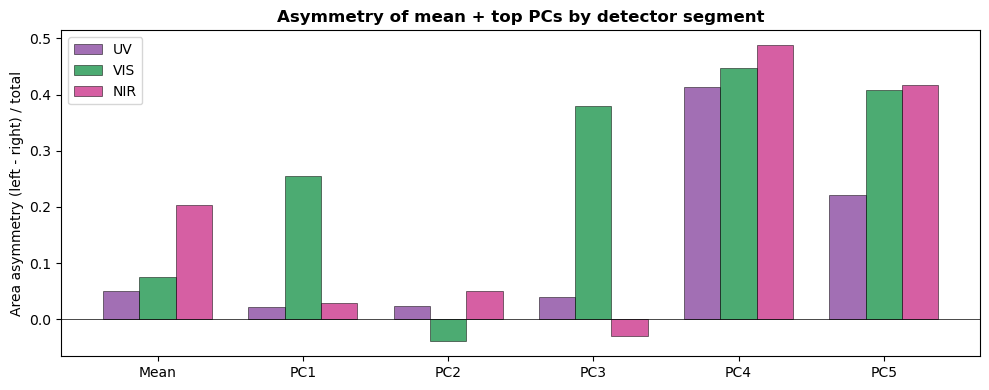

In [11]:
def asymmetry_metrics(profile, x):
    """Compute centroid, skewness, and area asymmetry of a peak profile."""
    mid = len(profile) // 2
    w = np.abs(profile)
    wsum = np.sum(w)
    centroid = np.sum(x * w) / wsum if wsum > 0 else 0
    mu = centroid
    var = np.sum(w * (x - mu) ** 2) / wsum
    skewness = np.sum(w * (x - mu) ** 3) / (wsum * var ** 1.5) if var > 1e-30 else 0
    area_left = np.trapezoid(np.abs(profile[:mid + 1]), x[:mid + 1])
    area_right = np.trapezoid(np.abs(profile[mid:]), x[mid:])
    total = area_left + area_right
    area_asym = (area_left - area_right) / total if total > 0 else 0
    return centroid, skewness, area_asym

# --- Per-segment asymmetry table ---
for seg_name in seg_names:
    if seg_name not in seg_pca_results:
        continue
    res = seg_pca_results[seg_name]
    n_show = min(5, res['components'].shape[0])
    x_seg = np.linspace(-1, 1, len(res['mean']))

    print(f'=== {seg_name} ({res["wl"][0]:.0f}-{res["wl"][-1]:.0f} nm) ===')
    print(f'{"Profile":>8s}  {"Centroid":>10s}  {"Skewness":>10s}  {"dArea":>10s}')
    c, s, a = asymmetry_metrics(res['mean'], x_seg)
    print(f'{"Mean":>8s}  {c:+10.4f}  {s:+10.4f}  {a:+10.4f}')
    for ci in range(n_show):
        c, s, a = asymmetry_metrics(res['components'][ci], x_seg)
        print(f'{"PC"+str(ci+1):>8s}  {c:+10.4f}  {s:+10.4f}  {a:+10.4f}')
    print()

# --- Summary plot: dArea for each segment's mean + top PCs ---
fig, ax = plt.subplots(figsize=(10, 4))
bar_width = 0.25
offsets = {'UV': -bar_width, 'VIS': 0, 'NIR': bar_width}

for seg_name in seg_names:
    if seg_name not in seg_pca_results:
        continue
    res = seg_pca_results[seg_name]
    n_show = min(5, res['components'].shape[0])
    x_seg = np.linspace(-1, 1, len(res['mean']))

    labels_list = ['Mean'] + [f'PC{ci+1}' for ci in range(n_show)]
    dareas = []
    for prof in [res['mean']] + [res['components'][ci] for ci in range(n_show)]:
        _, _, a = asymmetry_metrics(prof, x_seg)
        dareas.append(a)

    x_pos = np.arange(len(labels_list)) + offsets[seg_name]
    ax.bar(x_pos, dareas, width=bar_width, color=seg_colors_map[seg_name],
           edgecolor='k', lw=0.5, label=seg_name, alpha=0.7)

ax.set_xticks(np.arange(len(labels_list)))
ax.set_xticklabels(labels_list)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Area asymmetry (left - right) / total')
ax.set_title('Asymmetry of mean + top PCs by detector segment', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 3d. Reconstructing peaks from PC combinations

$$\hat{p}(x) = \bar{p}(x) + \sum_{i=1}^{N} w_i \cdot \mathrm{PC}_i(x)$$

Sliders control the weight applied to each PC (overall peak-shape PCA).

In [12]:
from ipywidgets import interact, FloatSlider

def reconstruct_peak(**kwargs):
    weights = np.array([kwargs[f'PC{i+1}'] for i in range(n_comp)])
    reconstructed = mean_peak + weights @ components
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.fill_between(x_norm, mean_peak, alpha=0.15, color='k')
    ax.plot(x_norm, mean_peak, 'k--', lw=1, alpha=0.5, label='mean')
    ax.plot(x_norm, reconstructed, 'b', lw=2, label='reconstructed')
    ax.set_xlabel('Normalised position')
    ax.set_ylabel('Normalised intensity')
    ax.legend()
    plt.tight_layout()
    plt.show()

sliders = {
    f'PC{i+1}': FloatSlider(min=-3*score_std[i], max=3*score_std[i],
                            step=score_std[i]/20, value=0,
                            description=f'PC{i+1}', readout_format='.3f')
    for i in range(n_comp)
}
interact(reconstruct_peak, **sliders);

interactive(children=(FloatSlider(value=0.0, description='PC1', max=6.252778564700572, min=-6.252778564700572,…

## 4. PC-based peak characterisation for downstream indexing

For each detected peak in a spectrum, we extract the same normalised window
used during PCA training and project it onto the principal components.
The PC scores encode the lineshape in a low-dimensional representation.

Peaks are classified by detector segment so that segment-specific
broadening characteristics can be compared.

In [13]:
from alibz.peaky_finder import PeakyFinder
from scipy.interpolate import interp1d

# --- PCA projection parameters (must match training) ---
# Use the half-window computed from per-segment GMM fits (cell above)
half_window = pca_half_window
print(f"Half-window: {half_window:.4f} nm (half of smallest segment mode)")

def extract_and_project(wavelength, spectrum, peak_params, mean_peak, components,
                        half_window, n_window_points=101):
    """Extract normalised windows around each peak and project onto PCs.

    Parameters
    ----------
    wavelength : array, shape (n_channels,)
    spectrum : array, shape (n_channels,)
    peak_params : array, shape (n_peaks, 4)
        Each row is [amp, mu, sigma, gamma].
    mean_peak : array, shape (n_window_points,)
    components : array, shape (n_components, n_window_points)
    half_window : float
        Half-window width in nm (must match PCA training).
    n_window_points : int

    Returns
    -------
    list of dict
        One dict per successfully extracted peak with keys:
        mu, amp, fwhm, PC1, PC2, ..., window (normalised profile).
    """
    wl_lo, wl_hi = wavelength[0], wavelength[-1]
    x_fixed = np.linspace(0, 1, n_window_points)
    results = []

    for i in range(peak_params.shape[0]):
        amp, mu, sigma, gamma = peak_params[i]
        lo, hi = mu - half_window, mu + half_window

        if lo < wl_lo or hi > wl_hi:
            continue

        mask = (wavelength >= lo) & (wavelength <= hi)
        wl_win = wavelength[mask]
        int_win = spectrum[mask].copy()

        if len(wl_win) < 5:
            continue

        # Same normalisation as PCA training
        baseline = np.linspace(int_win[0], int_win[-1], len(int_win))
        int_win -= baseline
        peak_range = np.max(int_win) - np.min(int_win)
        if peak_range <= 0:
            continue
        int_win -= np.min(int_win)
        int_win /= peak_range

        # Resample to fixed grid
        x_norm_local = np.linspace(0, 1, len(wl_win))
        window = interp1d(x_norm_local, int_win, kind='linear')(x_fixed)

        # Project onto PCs: scores = (window - mean) @ components.T
        scores = (window - mean_peak) @ components.T

        # FWHM
        fwhm_g = 2 * np.sqrt(2 * np.log(2)) * sigma
        fwhm_l = 2 * gamma
        fwhm = 0.5346 * fwhm_l + np.sqrt(0.2166 * fwhm_l**2 + fwhm_g**2)

        entry = {'mu': mu, 'amp': amp, 'sigma': sigma, 'gamma': gamma, 'fwhm': fwhm,
                 'window': window}
        for j, s in enumerate(scores):
            entry[f'PC{j+1}'] = s
        results.append(entry)

    return results

Half-window: 0.0841 nm (half of smallest segment mode)


In [14]:
# --- Fit a spectrum and project peaks onto PCs ---
path = '/Users/mwhittaker/Library/CloudStorage/GoogleDrive-mwhittaker@lbl.gov/My Drive/Postdocs/Xuan Cao/Data/LIBS/MW2-112/raw/'
finder = PeakyFinder(path)
finder.data.load_data()

spectrum_idx = 25
x = finder.data.data[spectrum_idx, 0]
y = finder.data.data[spectrum_idx, 1]

fit_dict = finder.fit_spectrum(x, y, n_sigma=0, subtract_background=True, plot=False)
peak_params = np.array(list(fit_dict['spectrum_dictionary'].values()))
print(f"Fitted {peak_params.shape[0]} peaks in spectrum {spectrum_idx}")

# Project each peak onto the PCA basis
peak_table = extract_and_project(x, y, peak_params, mean_peak, components, half_window)
print(f"Projected {len(peak_table)} peaks (remainder clipped by window edges)")

# Build a DataFrame for display
import pandas as pd
pc_cols = [f'PC{i+1}' for i in range(n_comp)]
df = pd.DataFrame(peak_table)
df = df[['mu', 'amp', 'fwhm'] + pc_cols].sort_values('mu').reset_index(drop=True)
df.columns = ['λ (nm)', 'Intensity', 'FWHM (nm)'] + pc_cols

print(f"\n--- Peak descriptors (spectrum {spectrum_idx}, {len(df)} peaks) ---")
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_columns', 15):
    display(df)

Fitted 741 peaks in spectrum 25
Projected 741 peaks (remainder clipped by window edges)

--- Peak descriptors (spectrum 25, 741 peaks) ---


,λ (nm),Intensity,FWHM (nm),PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,193.0909,24.6272,0.1214,-0.2411,-1.1827,0.4866,0.0065,-0.0403,-0.0244,-0.0832,0.0433,-0.0760,-0.0852
1,211.3379,37.8227,0.1974,1.0209,-0.8923,0.7207,0.0094,0.0314,0.0155,0.0417,0.0484,-0.0884,-0.0362
2,212.4132,61.6070,0.1517,0.6972,-0.9085,0.4553,-0.0099,0.0159,-0.0366,0.0087,0.0481,-0.0900,-0.0481
3,220.8145,21.2536,0.1455,0.4334,-0.9939,0.4933,-0.0027,-0.0003,-0.0272,-0.0170,0.0466,-0.0854,-0.0586
4,221.1000,43.9877,0.1813,-0.0517,-1.1671,0.6201,0.0158,-0.0309,0.0017,-0.0640,0.0436,-0.0756,-0.0782
...,...,...,...,...,...,...,...,...,...,...,...,...,...
736,855.2667,17.6974,0.3104,0.8069,-0.9319,0.6471,0.0058,0.0197,0.0018,0.0204,0.0477,-0.0871,-0.0444
737,866.1633,486.9863,0.3197,0.4528,-1.0383,0.6690,0.0129,-0.0016,0.0085,-0.0142,0.0459,-0.0816,-0.0584
738,867.5342,27.1984,0.2630,0.3532,-1.0607,0.6486,0.0125,-0.0073,0.0050,-0.0241,0.0455,-0.0807,-0.0623
739,891.0000,29.2864,0.3431,0.0137,-1.1957,0.7862,0.0298,-0.0293,0.0351,-0.0568,0.0431,-0.0726,-0.0761


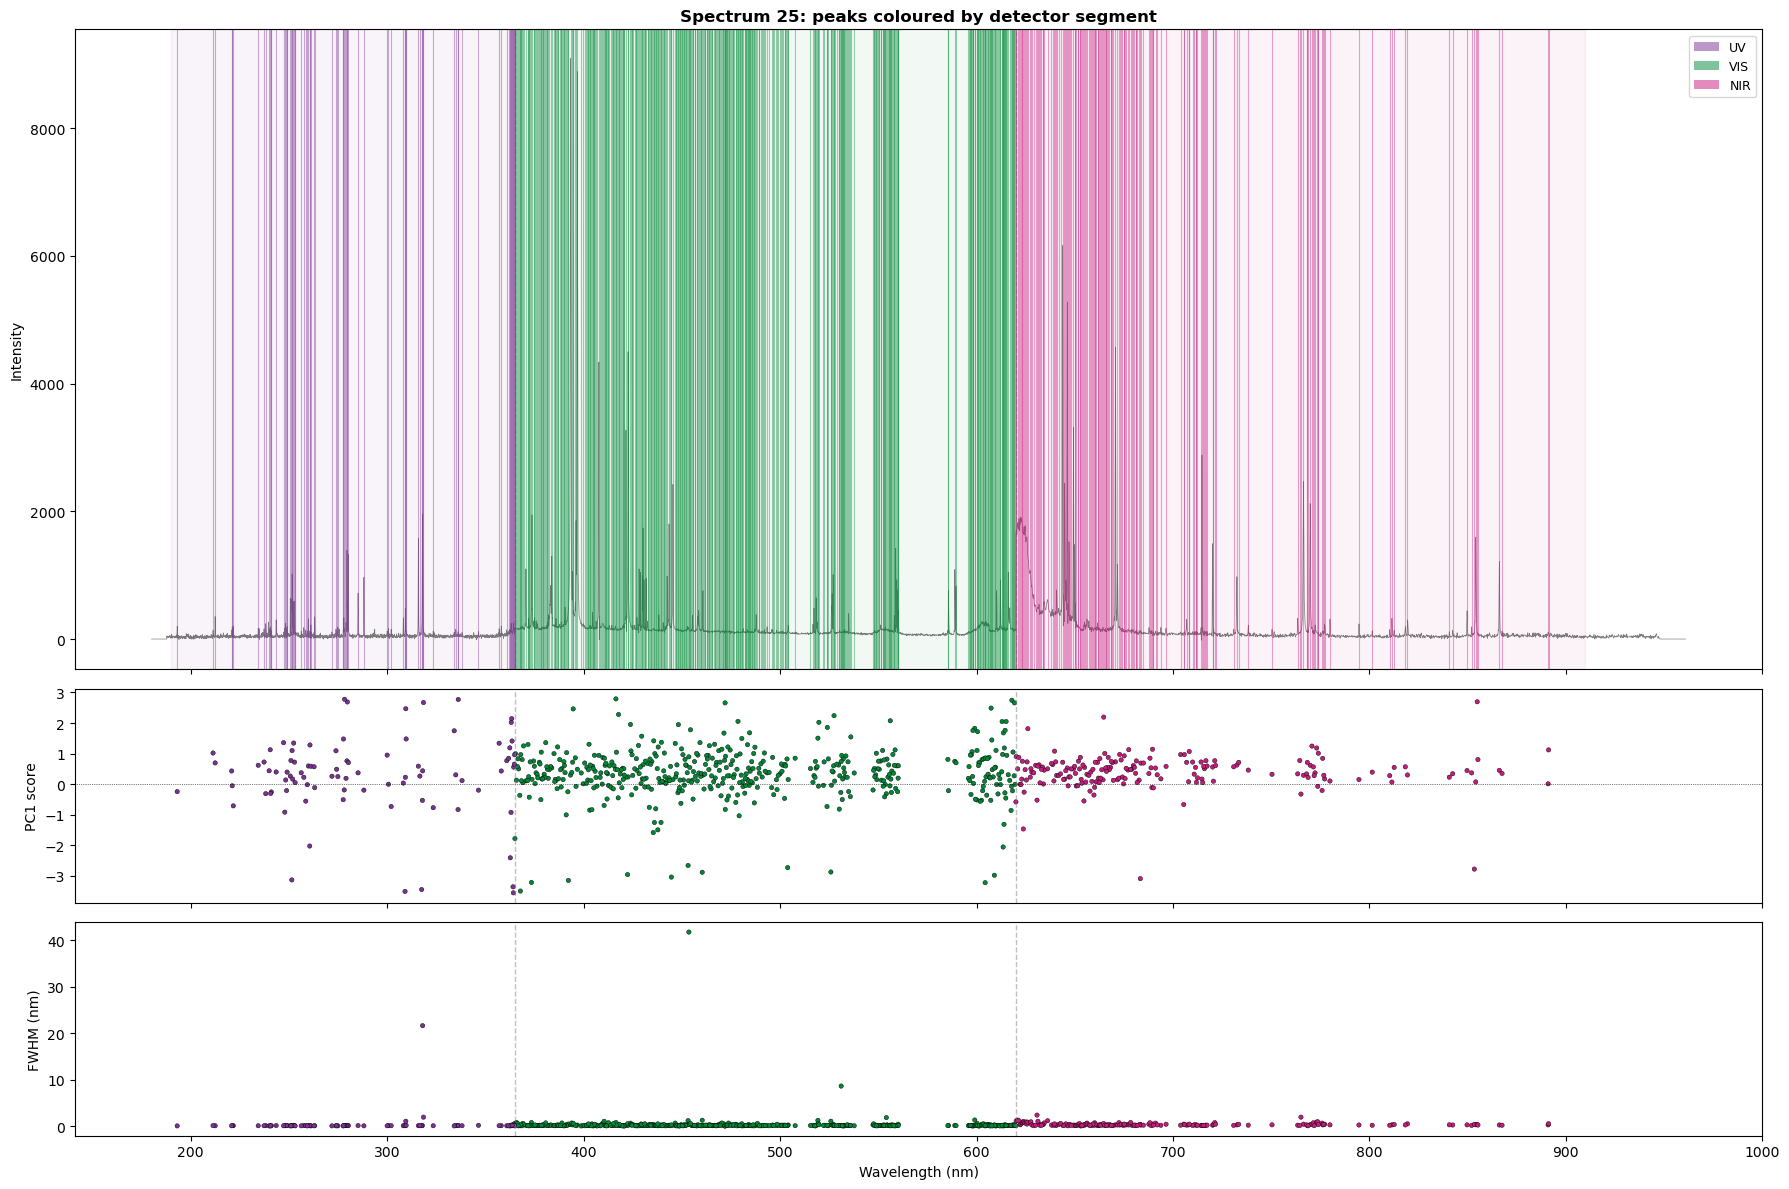


--- Per-segment PC1 statistics ---
  UV: n=87, mean=0.264, std=1.292, median=0.396
  VIS: n=468, mean=0.347, std=0.840, median=0.364
  NIR: n=186, mean=0.396, std=0.562, median=0.457


In [15]:
# Guard: skip if cell above failed (e.g. data path not available locally)
if 'peak_table' not in dir() or 'x' not in dir():
    print('Skipped: run cell above first (requires local spectrum data)')
else:

    # --- Visualise: spectrum with peaks coloured by detector segment ---
    fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True,
                             gridspec_kw={'height_ratios': [3, 1, 1]})
    
    seg_bounds = [190.0, 365.0, 620.0, 910.0]
    seg_names = ['UV', 'VIS', 'NIR']
    seg_cols = {'UV': '#7b3294', 'VIS': '#008837', 'NIR': '#c51b7d'}
    
    def get_segment(wl):
        if wl < 365.0: return 'UV'
        elif wl < 620.0: return 'VIS'
        else: return 'NIR'
    
    # Top panel: spectrum + peak markers coloured by segment
    ax = axes[0]
    ax.plot(x, y, 'k-', lw=0.5, alpha=0.5, label='Spectrum')
    
    # Shade segments
    for i, name in enumerate(seg_names):
        ax.axvspan(seg_bounds[i], seg_bounds[i+1], color=seg_cols[name], alpha=0.05)
    
    # Junction lines
    for jw in [365.0, 620.0]:
        ax.axvline(jw, color='gray', ls='--', lw=1, alpha=0.5)
    
    for p in peak_table:
        seg = get_segment(p['mu'])
        ax.axvline(p['mu'], color=seg_cols[seg], alpha=0.4, lw=0.8)
    
    # Legend patches
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=seg_cols[s], alpha=0.5, label=s) for s in seg_names]
    ax.legend(handles=handles, fontsize=9)
    ax.set_ylabel('Intensity')
    ax.set_title(f'Spectrum {spectrum_idx}: peaks coloured by detector segment', fontweight='bold')
    
    # Middle panel: PC1 score vs wavelength, coloured by segment
    ax = axes[1]
    pc1_vals = np.array([p['PC1'] for p in peak_table])
    mus = [p['mu'] for p in peak_table]
    colors = [seg_cols[get_segment(m)] for m in mus]
    ax.scatter(mus, pc1_vals, c=colors, s=10, edgecolors='k', linewidths=0.3)
    ax.axhline(0, color='k', ls=':', lw=0.5)
    for jw in [365.0, 620.0]:
        ax.axvline(jw, color='gray', ls='--', lw=1, alpha=0.5)
    ax.set_ylabel('PC1 score')
    
    # Bottom panel: FWHM vs wavelength, coloured by segment
    ax = axes[2]
    fwhms = [p['fwhm'] for p in peak_table]
    ax.scatter(mus, fwhms, c=colors, s=10, edgecolors='k', linewidths=0.3)
    for jw in [365.0, 620.0]:
        ax.axvline(jw, color='gray', ls='--', lw=1, alpha=0.5)
    ax.set_ylabel('FWHM (nm)')
    ax.set_xlabel('Wavelength (nm)')
    
    plt.tight_layout()
    plt.show()
    
    # --- Per-segment PC score summary ---
    print('\n--- Per-segment PC1 statistics ---')
    for name in seg_names:
        seg_pc1 = [p['PC1'] for p in peak_table if get_segment(p['mu']) == name]
        if seg_pc1:
            seg_pc1 = np.array(seg_pc1)
            print(f'  {name}: n={len(seg_pc1)}, '
                  f'mean={seg_pc1.mean():.3f}, std={seg_pc1.std():.3f}, '
                  f'median={np.median(seg_pc1):.3f}')